In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Model Saving
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("fab_energy_dataset_500-2.csv")

df.head()

,date,tool_id,process_type,wafers_processed,runtime_hours,idle_hours,cleanroom_temp,humidity,shift,energy_kwh
0,01-01-2026,T4,Etch,156,19.356292,5.177951,21.783331,41.499624,Day,787.06
1,01-01-2026,T3,Deposition,51,18.663985,7.569869,20.003115,54.883173,Day,666.29
2,01-01-2026,T1,Deposition,285,10.276749,4.673423,21.599444,40.699985,Night,1044.23
3,01-01-2026,T4,Lithography,113,15.601155,7.019583,22.721230,46.757489,Night,833.80
4,01-01-2026,T2,Etch,63,19.700768,3.132296,20.390688,50.263495,Night,618.01


In [4]:
df.shape

(500, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              500 non-null    object 
 1   tool_id           500 non-null    object 
 2   process_type      500 non-null    object 
 3   wafers_processed  500 non-null    int64  
 4   runtime_hours     500 non-null    float64
 5   idle_hours        500 non-null    float64
 6   cleanroom_temp    500 non-null    float64
 7   humidity          500 non-null    float64
 8   shift             500 non-null    object 
 9   energy_kwh        500 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 39.2+ KB


In [6]:
df.describe()

,wafers_processed,runtime_hours,idle_hours,cleanroom_temp,humidity,energy_kwh
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,172.800000,15.972690,4.494852,22.004036,47.560978,907.88344
std,72.506236,3.417729,2.069540,1.115659,4.397342,179.46540
min,50.000000,10.045806,1.008657,20.003115,40.004988,455.07000
25%,108.000000,12.943922,2.611308,21.085599,43.819608,776.76000
50%,171.000000,15.821570,4.699990,22.028169,47.615616,901.35000
75%,236.000000,18.963818,6.228908,22.923356,51.412696,1044.56500
max,300.000000,21.992965,7.998024,23.990962,54.965389,1347.51000


In [7]:
df.isnull().sum()

date                0
tool_id             0
process_type        0
wafers_processed    0
runtime_hours       0
idle_hours          0
cleanroom_temp      0
humidity            0
shift               0
energy_kwh          0
dtype: int64

In [8]:
df['process_type'].value_counts()

process_type
Deposition     174
Lithography    168
Etch           158
Name: count, dtype: int64

In [9]:
df['shift'].value_counts()

shift
Day      264
Night    236
Name: count, dtype: int64

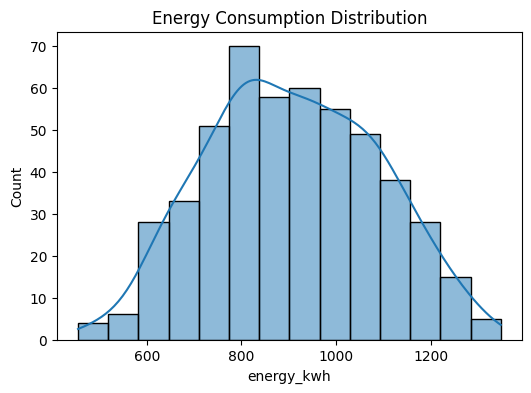

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['energy_kwh'], kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

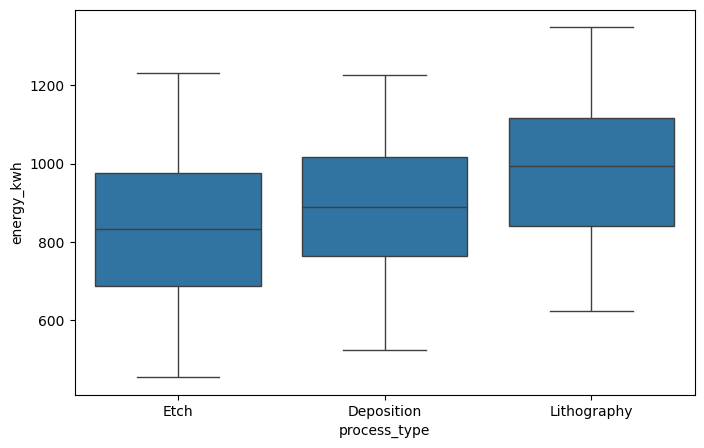

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='process_type', y='energy_kwh', data=df)
plt.show()

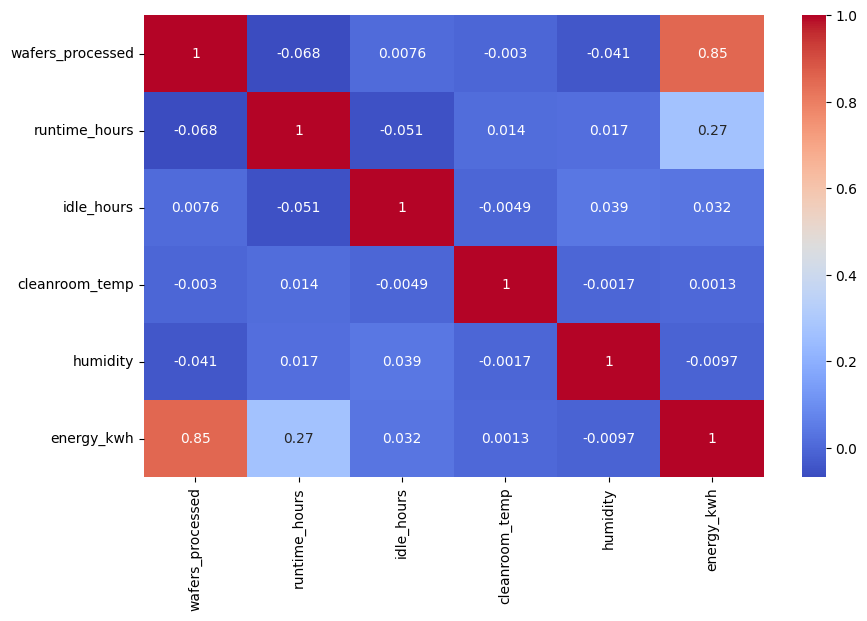

In [12]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

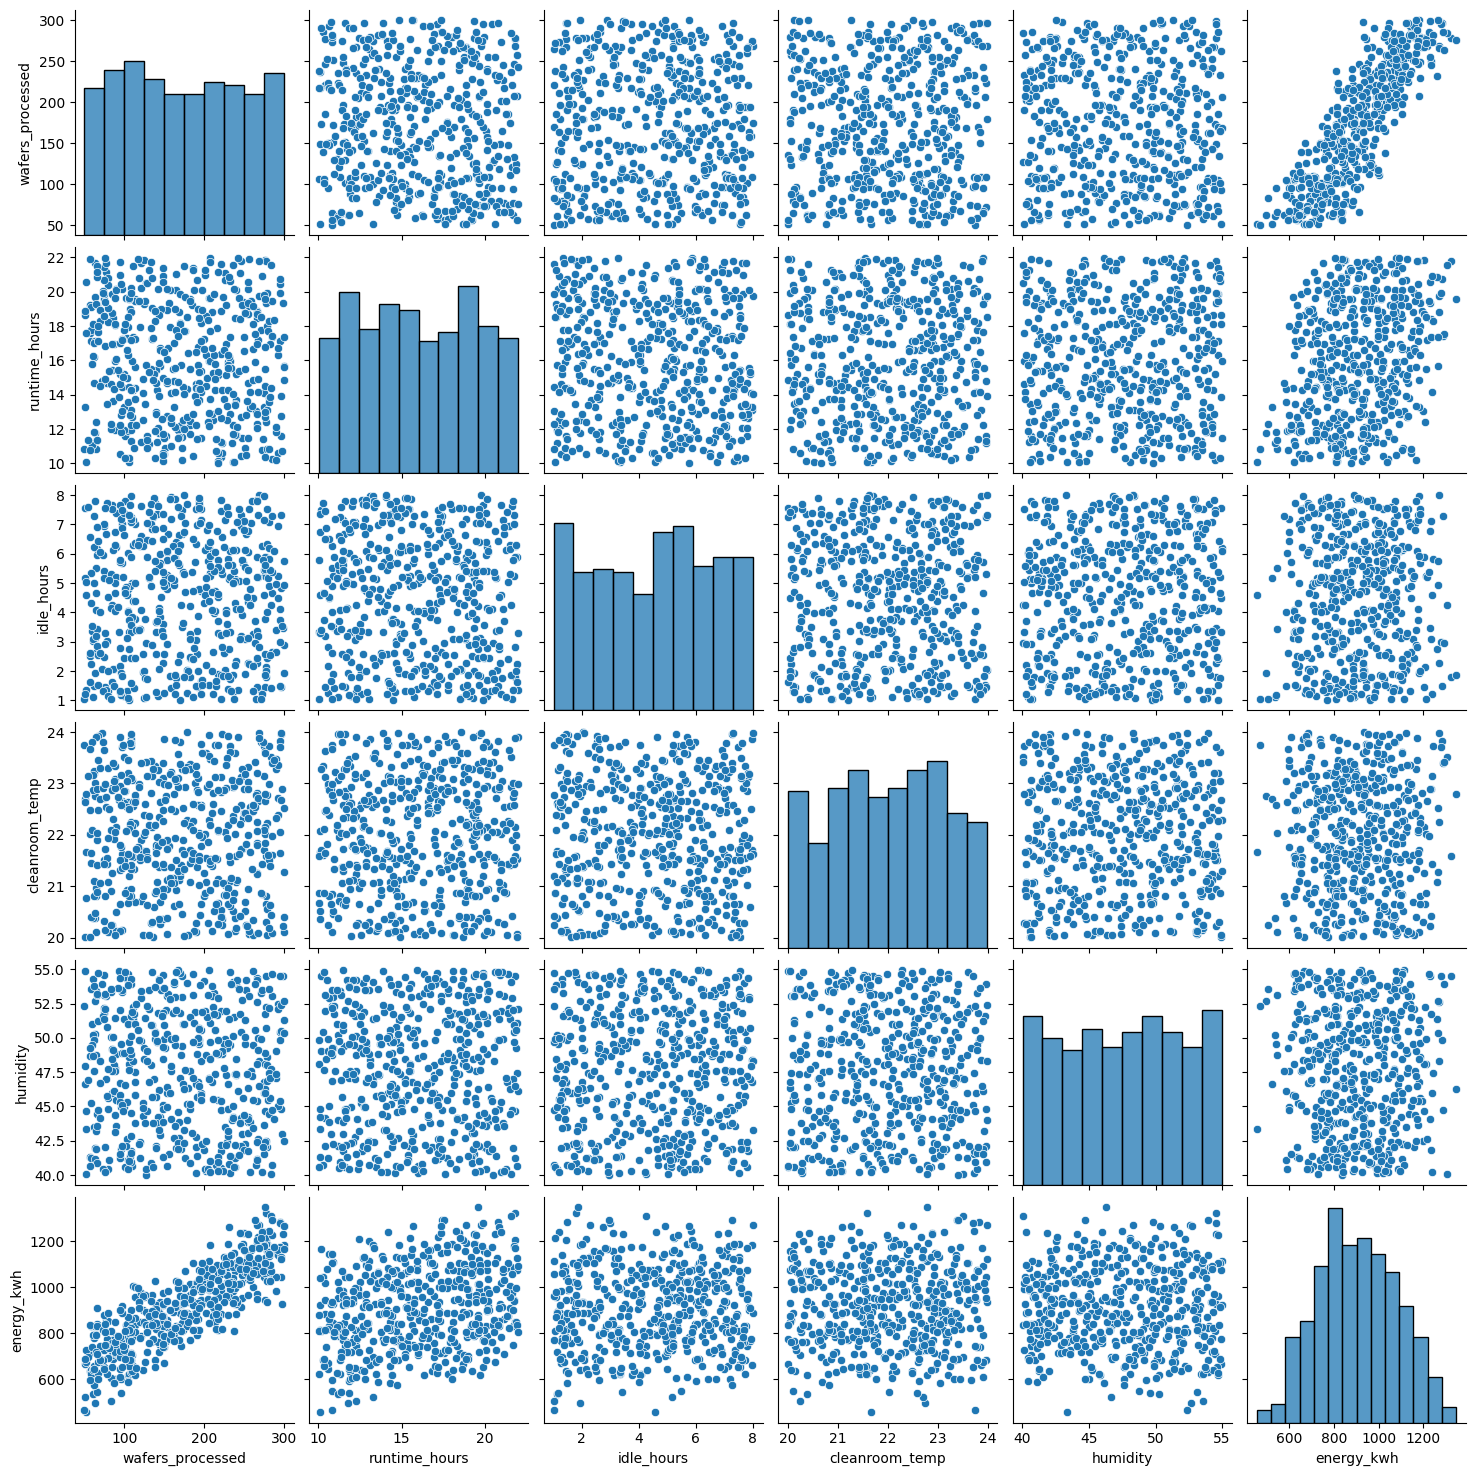

In [13]:
sns.pairplot(df)
plt.show()

In [14]:
threshold = df['energy_kwh'].median()

df['high_energy'] = np.where(df['energy_kwh'] > threshold, 1, 0)

In [15]:
df = df.drop(['date', 'energy_kwh'], axis=1)

In [16]:
le_tool = LabelEncoder()
le_process = LabelEncoder()
le_shift = LabelEncoder()

df['tool_id'] = le_tool.fit_transform(df['tool_id'])
df['process_type'] = le_process.fit_transform(df['process_type'])
df['shift'] = le_shift.fit_transform(df['shift'])

In [17]:
X = df.drop('high_energy', axis=1)
y = df['high_energy']

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        44
           1       0.96      0.86      0.91        56

    accuracy                           0.90       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.91      0.90      0.90       100



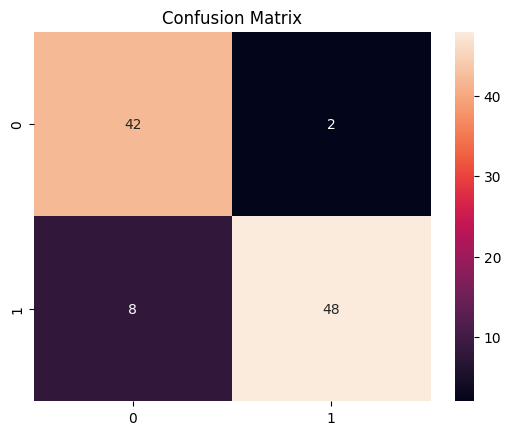

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

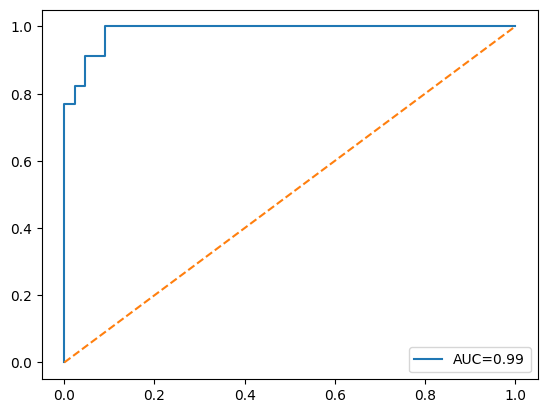

In [23]:
y_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC="+str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

In [24]:
pickle.dump(model, open("energy_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(le_tool, open("le_tool.pkl", "wb"))
pickle.dump(le_process, open("le_process.pkl", "wb"))
pickle.dump(le_shift, open("le_shift.pkl", "wb"))